# EfficientNet-B4 Training Pipeline

Fine-tunes a pretrained EfficientNet-B4 backbone for 3-class chest X-ray classification: `NORMAL`, `BACTERIAL_PNEUMONIA`, and `VIRAL_PNEUMONIA`.

## Training strategy

| Phase | Epochs | Layers trained | Learning rate |
|---|---|---|---|
| 1 — Head warm-up | 1–3 | Classifier head only | `1e-4` |
| 2 — Fine-tuning | 4+ | Head + last 4 feature blocks | `1e-5` |

EfficientNet-B4's features are accessed via `model.features[-4:]`. Unfreezing only the last four blocks exposes the high-level semantic layers to fine-tuning while preserving the general low-level feature representations from ImageNet pretraining.

## Key design decisions
- **Class-weighted loss**: corrects for imbalance between bacterial (most samples) and viral (fewest) classes
- **Label smoothing (0.05)**: lighter than ResNet50 — EfficientNet already incorporates stochastic depth and dropout within its MBConv blocks
- **Mixed precision (AMP)**: enabled when CUDA is available for faster training throughput
- **Early stopping (patience=4)**: saves compute when validation loss plateaus

## Outputs
- `EfficientNet-B4_pneumonia.pth` — best model weights
- `classes.json` — class index-to-label mapping

In [1]:
# Install this once
!pip install import-ipynb
!pip install import-ipynb scikit-learn

## DataLoader Import

Imports the cleaned datasets and preprocessing transforms from `Preprocessing_Pipeline.ipynb`. This gives us:
- `prep.train_dataset` / `prep.val_dataset` / `prep.test_dataset` — `ImageFolder` datasets after autoencoder-based outlier removal
- `prep.train_dataset.classes` — ordered class name list used to configure the model output layer

The full preprocessing pipeline (CLAHE, noise reduction, normalisation, augmentations) is already embedded in each dataset object. No additional transforms are applied here.

Cleaning datasets using autoencoder...

Processing class 0...


Class 0 Epoch 1, Total Loss: 33.2285


Class 0 Epoch 2, Total Loss: 19.2531


Class 0 Epoch 3, Total Loss: 17.8663


Class 0: removed 127 samples

Processing class 1...


...

Class 1: removed 8 samples

Processing class 2...


Class 2 Epoch 1, Total Loss: 4.0763


Class 2 Epoch 2, Total Loss: 4.0995


Class 2: removed 5 samples

Balancing train dataset...
Before balancing: {np.int64(0): np.int64(2403), np.int64(1): np.int64(1273), np.int64(2): np.int64(1277)}
After balancing: {np.int64(0): np.int64(1273), np.int64(1): np.int64(1273), np.int64(2): np.int64(1273)}
Classes: ['BACTERIAL_PNEUMONIA', 'NORMAL', 'VIRAL_PNEUMONIA']
Train size: 3819
Validation size: 186
Test size: 604


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.015686303..1.0217083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0296907].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0336821].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0017517].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.007843137..1.0217083].


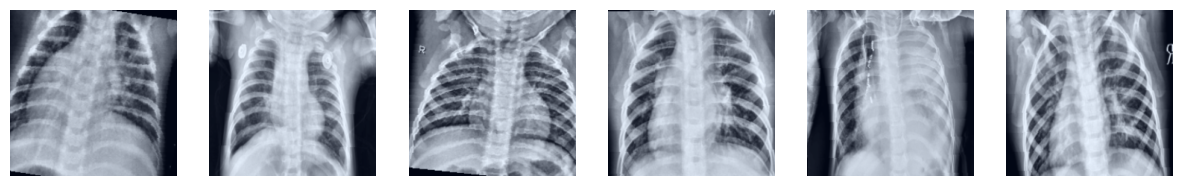

🔹 Train Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 1273 (33.33%)
NORMAL: 1273 (33.33%)
VIRAL_PNEUMONIA: 1273 (33.33%)

🔹 Test Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 234 (38.74%)
NORMAL: 227 (37.58%)
VIRAL_PNEUMONIA: 143 (23.68%)
🔹 Validation Dataset
Class Distribution:

BACTERIAL_PNEUMONIA: 62 (33.33%)
NORMAL: 62 (33.33%)
VIRAL_PNEUMONIA: 62 (33.33%)


In [2]:
import import_ipynb
import Preprocessing_Pipeline as prep

In [3]:
import copy
import json
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader

from torchvision import models

from sklearn.metrics import (
    classification_report,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using:", device)

Using: cuda


In [5]:
train_loader = DataLoader(prep.train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(prep.val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(prep.test_dataset, batch_size=32, shuffle=False)

NUM_CLASSES = len(prep.train_dataset.classes)

## EfficientNet-B4 Architecture

EfficientNet-B4 (~19M parameters) uses **compound scaling** to jointly increase network depth, width, and input resolution according to a fixed ratio. It was designed to maximise accuracy-per-FLOP on natural image benchmarks.

The standard classifier head (`classifier[1]: Linear(in_features → 1000)`) is replaced with:
```
Linear(in_features → num_classes)
```
No explicit Dropout is added here — EfficientNet's MBConv blocks already incorporate stochastic depth and per-block dropout, providing sufficient regularisation for transfer learning.

In [6]:
model = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.DEFAULT)
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, 512),
    nn.BatchNorm1d(512),
    nn.SiLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES)
)
model = model.to(device)

### Phase 1: Head-Only Training

All backbone parameters are frozen — only the newly added classifier head will receive gradient updates for the first `FREEZE_EPOCHS` epochs. This prevents the randomly-initialised head from destroying pretrained feature representations during early training when its gradients are large and noisy.

In [7]:
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

### Class Weighting

Computes inverse-frequency weights for each class: `weight[i] = total_samples / count[i]`. This means errors on the small `VIRAL_PNEUMONIA` class are penalised proportionally more than errors on the larger `BACTERIAL_PNEUMONIA` class. The weights are passed directly to `CrossEntropyLoss`, making the loss surface reflect clinical priority rather than dataset frequency.

In [8]:
counts = Counter(prep.train_dataset.targets)
total = sum(counts.values())
class_weights = [
    total / counts[i]
    for i in range(len(counts))
]
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

## Training Configuration

| Parameter | Value | Rationale |
|---|---|---|
| Loss function | `CrossEntropyLoss` (weighted) | Class weights inversely proportional to sample count; penalises minority-class errors more heavily |
| Label smoothing | `0.05` | Lighter smoothing — EfficientNet's built-in stochastic depth provides additional regularisation |
| Optimizer | `Adam` | Adaptive per-parameter learning rates; robust without extensive LR tuning |
| Head LR (Phase 1) | `1e-4` | Fast convergence for the new classifier head |
| Fine-tune LR (Phase 2) | `1e-5` | Conservative rate to preserve pretrained EfficientNet features |
| Weight decay | `1e-4` | L2 regularisation |
| LR scheduler | `ReduceLROnPlateau` | Multiplies LR by 0.3 after 2 epochs without val loss improvement |
| Max epochs | `20` | Upper bound; early stopping typically triggers earlier |
| Freeze epochs | `3` | Epochs before last-4-block unfreezing |
| Early stop patience | `4` | Epochs to wait before halting training |
| Gradient clipping | `2.0` | Caps global gradient norm to prevent destructive updates from bad batches |

In [9]:
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
optimizer = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model.parameters()
    ),
    lr=1e-4,
    weight_decay=1e-4
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.3)

EPOCHS = 20
FREEZE_EPOCHS = 3
PATIENCE = 4

best_val_loss = float('inf')
epochs_no_improve = 0

best_model_weights = copy.deepcopy(model.state_dict())

use_amp = torch.cuda.is_available()
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


C:\Users\noora\AppData\Local\Temp\ipykernel_7516\323792533.py:22: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)


## Training Loop

`train_one_epoch` runs one full pass over the training set. Key implementation details:

- **Mixed precision** (`torch.cuda.amp.autocast`): forward pass computes in float16 where safe, reducing GPU memory and increasing throughput. `GradScaler` rescales gradients back to float32 before the optimizer step to prevent underflow
- **Gradient clipping** (`clip_grad_norm_=2.0`): caps the global L2 norm of all gradients, preventing a single bad batch from causing a destructive parameter update
- `optimizer.zero_grad()` is called before the forward pass (not after), which is the recommended pattern when using gradient scaling
- Returns average batch loss and per-epoch accuracy for tracking

In [10]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    loop = tqdm(loader, desc="Training", leave=False)
    for images, labels in loop:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        loop.set_postfix(loss=loss.item())
    return (total_loss / len(loader), correct / total)

## Evaluation Loop

`evaluate` runs a full pass over a dataloader under `torch.no_grad()`, which disables gradient computation and approximately halves memory usage. This function is used identically for both validation (after each training epoch) and final test evaluation, ensuring both are computed the same way.

In [11]:
def evaluate(model, loader):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)
            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return (
        total_loss / len(loader),
        correct / total,
        np.array(all_probs),
        np.array(all_preds),
        np.array(all_labels)
    )

## Main Training Loop

Runs the full training cycle with two-phase fine-tuning, live loss plotting, and early stopping:

1. **Epochs 1–`FREEZE_EPOCHS`**: only the classification head is trained; backbone is frozen
2. **At epoch `FREEZE_EPOCHS`**: the last 4 feature blocks are unfrozen and the optimizer is rebuilt at a lower learning rate to fine-tune pretrained weights gently
3. **Each epoch**: train → validate → step the LR scheduler → check early stopping → update live loss plot
4. **Best model checkpointing**: the state dict is saved in memory whenever validation loss reaches a new minimum. If early stopping triggers, training ends with the best weights already captured and ready to restore


Epoch 1/20


Training:   0%|          | 0/120 [00:00<?, ?it/s]C:\Users\noora\AppData\Local\Temp\ipykernel_7516\4267830533.py:11: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
                                                                       

Train Loss: 0.8833 | Train Acc: 0.6004
Val Loss: 0.7502 | Val Acc: 0.7151
Generalization Gap: -0.1146
⚠️ Possible Underfitting (High Bias)
✅ Best model updated


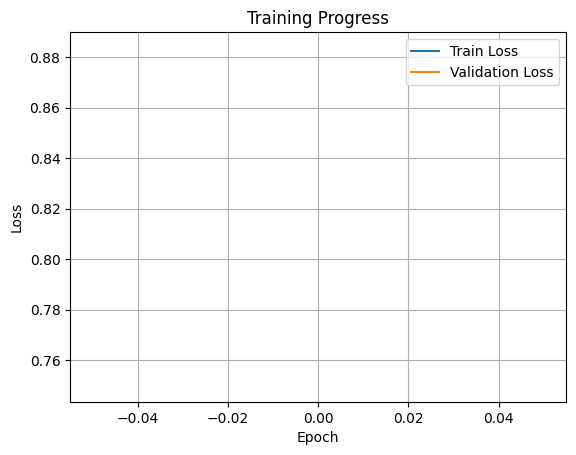


Epoch 2/20


Train Loss: 0.7541 | Train Acc: 0.6782
Val Loss: 0.7201 | Val Acc: 0.7204
Generalization Gap: -0.0422
⚠️ Possible Underfitting (High Bias)
✅ Best model updated


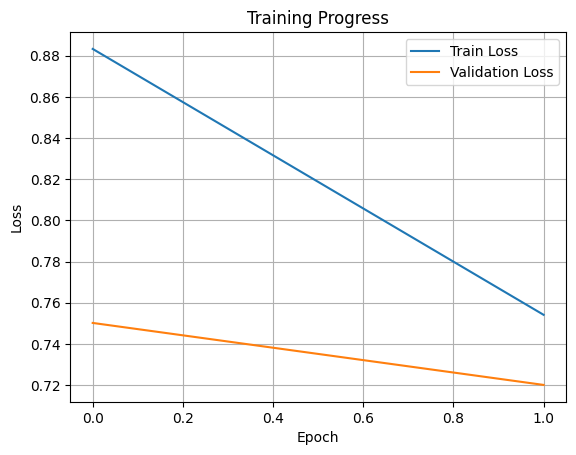


Epoch 3/20


Train Loss: 0.7271 | Train Acc: 0.6984
Val Loss: 0.7016 | Val Acc: 0.7473
Generalization Gap: -0.0490
⚠️ Possible Underfitting (High Bias)
✅ Best model updated


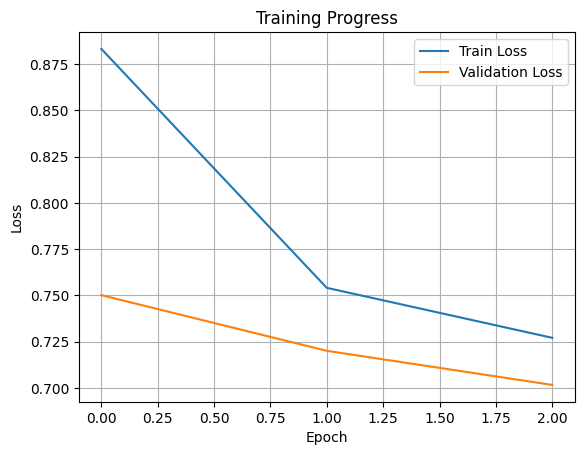


Epoch 4/20
🚀 Unfreezing EfficientNet backbone...


Train Loss: 0.7214 | Train Acc: 0.7138
Val Loss: 0.6914 | Val Acc: 0.7634
Generalization Gap: -0.0496
✅ Good Bias-Variance Tradeoff
✅ Best model updated


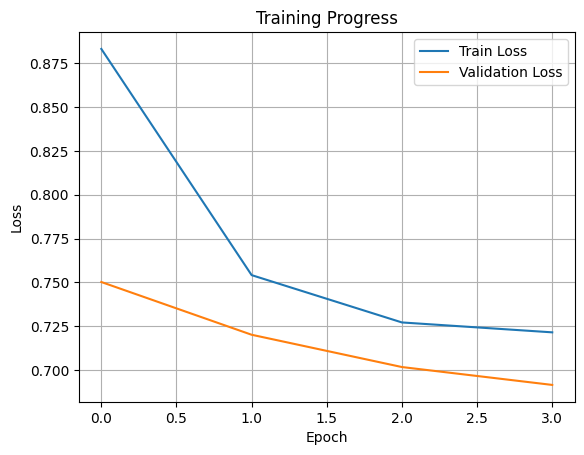


Epoch 5/20


Train Loss: 0.7259 | Train Acc: 0.6997
Val Loss: 0.7198 | Val Acc: 0.7527
Generalization Gap: -0.0530
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 1 epochs


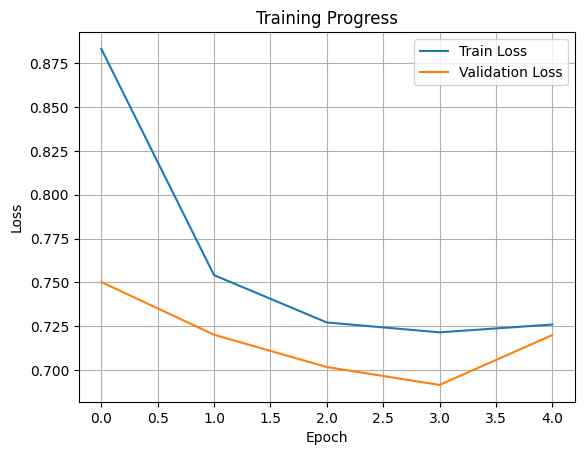


Epoch 6/20


Train Loss: 0.7146 | Train Acc: 0.7073
Val Loss: 0.6856 | Val Acc: 0.7796
Generalization Gap: -0.0723
✅ Good Bias-Variance Tradeoff
✅ Best model updated


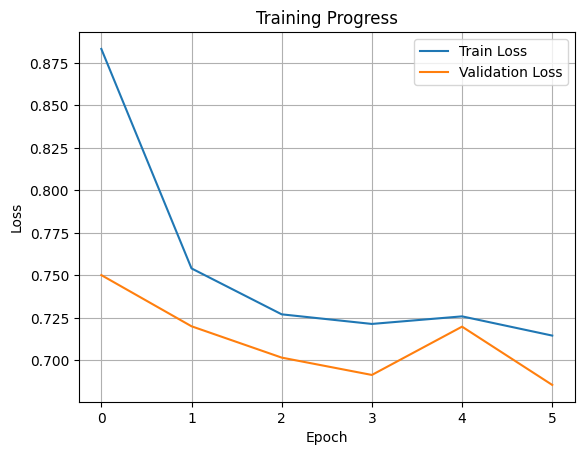


Epoch 7/20


Train Loss: 0.7048 | Train Acc: 0.7073
Val Loss: 0.6371 | Val Acc: 0.7957
Generalization Gap: -0.0884
✅ Good Bias-Variance Tradeoff
✅ Best model updated


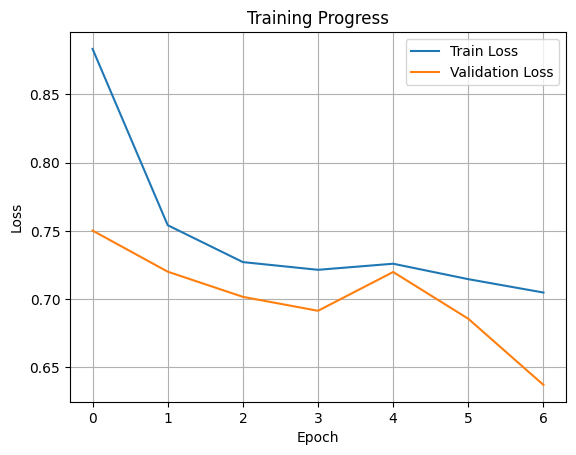


Epoch 8/20


Train Loss: 0.7043 | Train Acc: 0.7169
Val Loss: 0.6745 | Val Acc: 0.7742
Generalization Gap: -0.0573
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 1 epochs


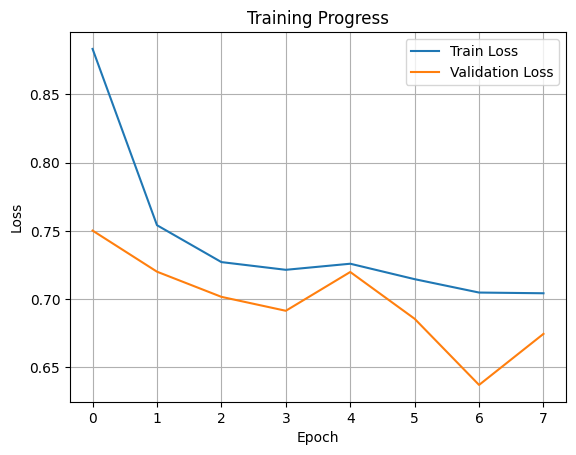


Epoch 9/20


Train Loss: 0.6895 | Train Acc: 0.7243
Val Loss: 0.6417 | Val Acc: 0.7849
Generalization Gap: -0.0607
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 2 epochs


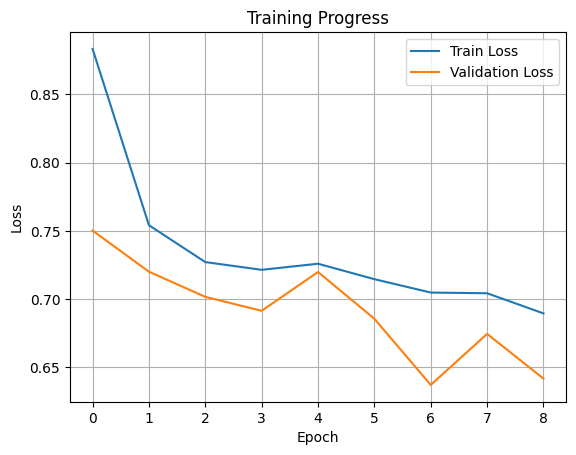


Epoch 10/20


Train Loss: 0.6935 | Train Acc: 0.7203
Val Loss: 0.6380 | Val Acc: 0.7742
Generalization Gap: -0.0538
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 3 epochs


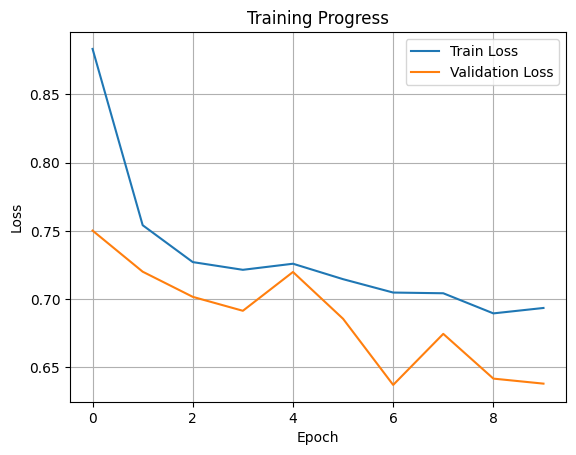


Epoch 11/20


Train Loss: 0.6884 | Train Acc: 0.7235
Val Loss: 0.6371 | Val Acc: 0.7849
Generalization Gap: -0.0615
✅ Good Bias-Variance Tradeoff
✅ Best model updated


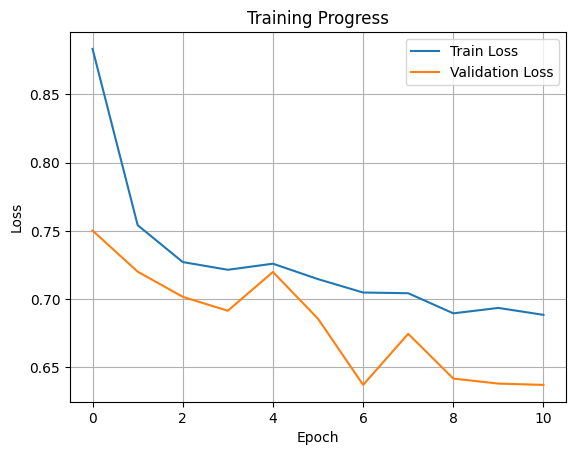


Epoch 12/20


Train Loss: 0.6777 | Train Acc: 0.7245
Val Loss: 0.6686 | Val Acc: 0.7903
Generalization Gap: -0.0658
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 1 epochs


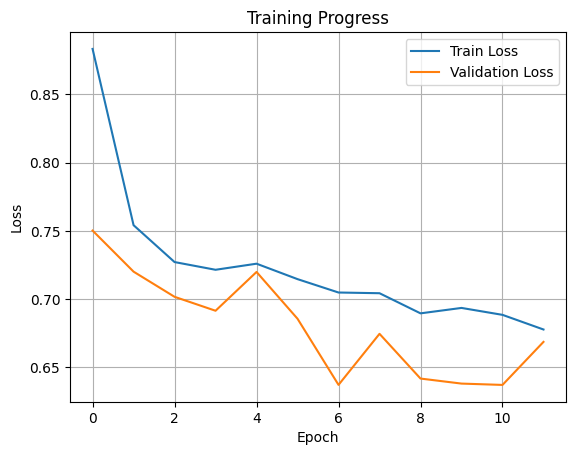


Epoch 13/20


Train Loss: 0.6905 | Train Acc: 0.7279
Val Loss: 0.6329 | Val Acc: 0.7796
Generalization Gap: -0.0516
✅ Good Bias-Variance Tradeoff
✅ Best model updated


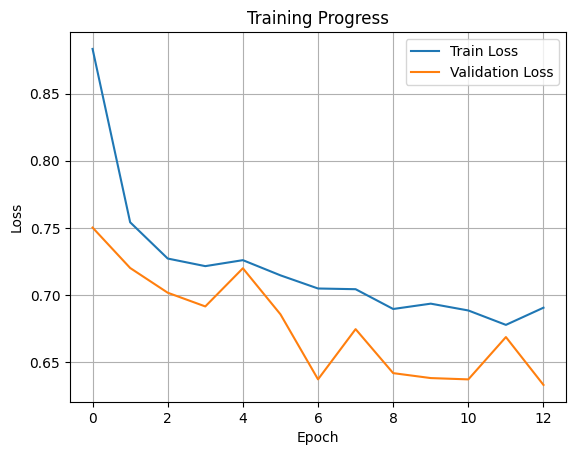


Epoch 14/20


Train Loss: 0.6811 | Train Acc: 0.7282
Val Loss: 0.6654 | Val Acc: 0.7849
Generalization Gap: -0.0567
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 1 epochs


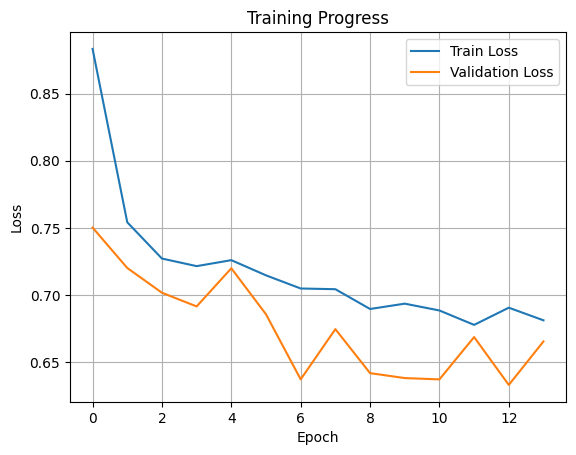


Epoch 15/20


Train Loss: 0.6691 | Train Acc: 0.7285
Val Loss: 0.6666 | Val Acc: 0.7849
Generalization Gap: -0.0565
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 2 epochs


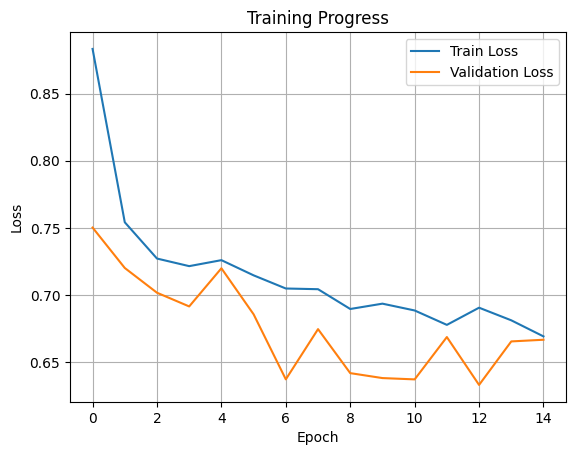


Epoch 16/20


Train Loss: 0.6760 | Train Acc: 0.7319
Val Loss: 0.6228 | Val Acc: 0.8011
Generalization Gap: -0.0692
✅ Good Bias-Variance Tradeoff
✅ Best model updated


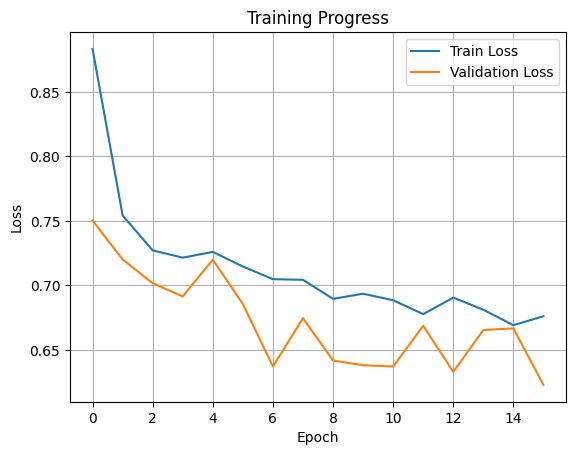


Epoch 17/20


Train Loss: 0.6709 | Train Acc: 0.7290
Val Loss: 0.6527 | Val Acc: 0.7849
Generalization Gap: -0.0560
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 1 epochs


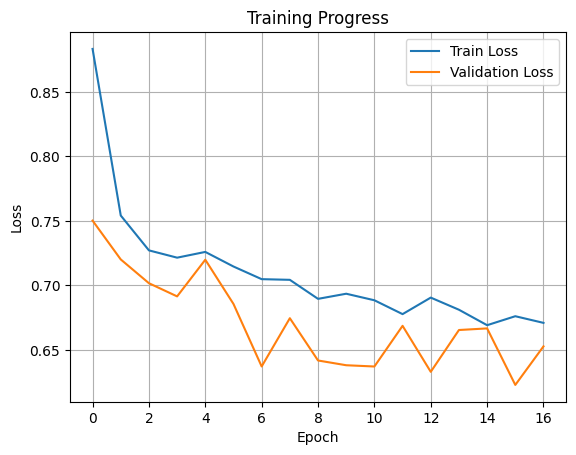


Epoch 18/20


Train Loss: 0.6747 | Train Acc: 0.7282
Val Loss: 0.6359 | Val Acc: 0.7849
Generalization Gap: -0.0567
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 2 epochs


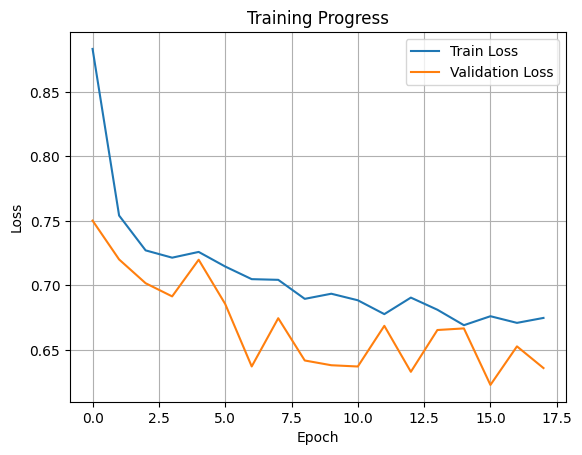


Epoch 19/20


Train Loss: 0.6868 | Train Acc: 0.7227
Val Loss: 0.6644 | Val Acc: 0.7796
Generalization Gap: -0.0569
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 3 epochs


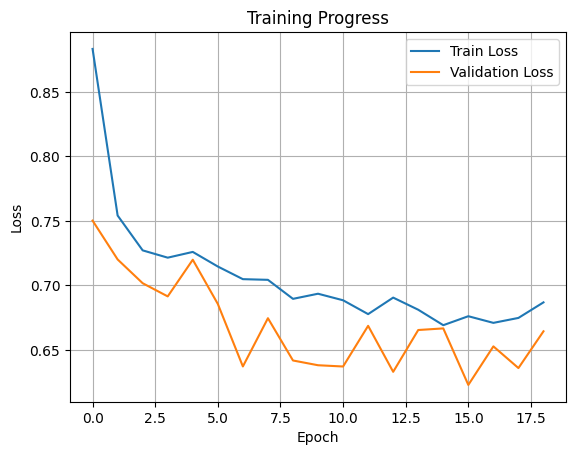


Epoch 20/20


Train Loss: 0.6818 | Train Acc: 0.7193
Val Loss: 0.6332 | Val Acc: 0.7796
Generalization Gap: -0.0603
✅ Good Bias-Variance Tradeoff
⚠️ No improvement for 4 epochs
🛑 Early stopping triggered


In [12]:
plt.ion()
for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    if epoch == FREEZE_EPOCHS:
        print("🚀 Unfreezing EfficientNet backbone...")
        for param in model.features[-4:].parameters():
            param.requires_grad = True
        optimizer = optim.AdamW(
            filter(
                lambda p: p.requires_grad,
                model.parameters()
            ),
            lr=1e-5,
            weight_decay=1e-4
        )
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=2, factor=0.3)
    train_loss, train_acc = train_one_epoch(model, train_loader)
    val_loss, val_acc, _, _, _ = evaluate(model, val_loader)
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f}"
    )
    print(
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )
    gap = train_acc - val_acc
    print(f"Generalization Gap: {gap:.4f}")
    if gap > 0.10:
        print(
            "⚠️ Possible Overfitting "
            "(High Variance)"
        )
    elif gap < 0.02 and val_acc < 0.75:
        print(
            "⚠️ Possible Underfitting "
            "(High Bias)"
        )
    else:
        print(
            "✅ Good Bias-Variance Tradeoff"
        )
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        best_model_weights = copy.deepcopy(model.state_dict())
        print("✅ Best model updated")
    else:
        epochs_no_improve += 1
        print(
            f"⚠️ No improvement for "
            f"{epochs_no_improve} epochs"
        )
    if epochs_no_improve >= PATIENCE:
        print("🛑 Early stopping triggered")
        break

    plt.clf()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training Progress")
    plt.legend()
    plt.grid()
    plt.pause(0.1)

plt.ioff()
plt.show()

## Restore Best Weights and Evaluate

Restores the model state dict that achieved the lowest validation loss during training, then runs a single final evaluation on the held-out test set. The test set is touched only here — it was never used for training decisions or scheduler stepping.

In [13]:
model.load_state_dict(best_model_weights)

<All keys matched successfully>

In [14]:
test_loss, test_acc, probs, preds, labels = evaluate(model, test_loader)
print("TEST RESULTS:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

TEST RESULTS:
Test Loss: 0.6753
Test Accuracy: 0.7881


### F1 Score

Weighted F1 accounts for class imbalance by averaging per-class F1 scores weighted by support (number of true instances per class). This is a more honest summary metric than accuracy for an imbalanced 3-class problem.

In [15]:
f1 = f1_score(
    labels,
    preds,
    average='weighted'
)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7894


In [16]:
torch.save(model.state_dict(), "EfficientNet-B4_pneumonia.pth")

import json
with open("classes.json", "w") as f:
    json.dump(prep.train_dataset.classes, f)

### Classification Report

Per-class breakdown of precision, recall, and F1-score on the test set. This is more informative than overall accuracy for an imbalanced dataset — a model that always predicts `NORMAL` or `BACTERIAL_PNEUMONIA` could still score high accuracy while completely missing `VIRAL_PNEUMONIA`. The per-class recall column is especially important in a medical screening context where false negatives carry clinical risk.

In [17]:
print(
    classification_report(labels, preds, target_names=prep.train_dataset.classes)
)

                     precision    recall  f1-score   support

BACTERIAL_PNEUMONIA       0.87      0.85      0.86       234
             NORMAL       0.80      0.76      0.78       227
    VIRAL_PNEUMONIA       0.66      0.73      0.70       143

           accuracy                           0.79       604
          macro avg       0.78      0.78      0.78       604
       weighted avg       0.79      0.79      0.79       604



## ROC_AUC Curves

In [18]:
labels_bin = label_binarize(
    labels,
    classes=np.arange(NUM_CLASSES)
)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(NUM_CLASSES):

    fpr[i], tpr[i], _ = roc_curve(
        labels_bin[:, i],
        probs[:, i]
    )

    roc_auc[i] = auc(
        fpr[i],
        tpr[i]
    )

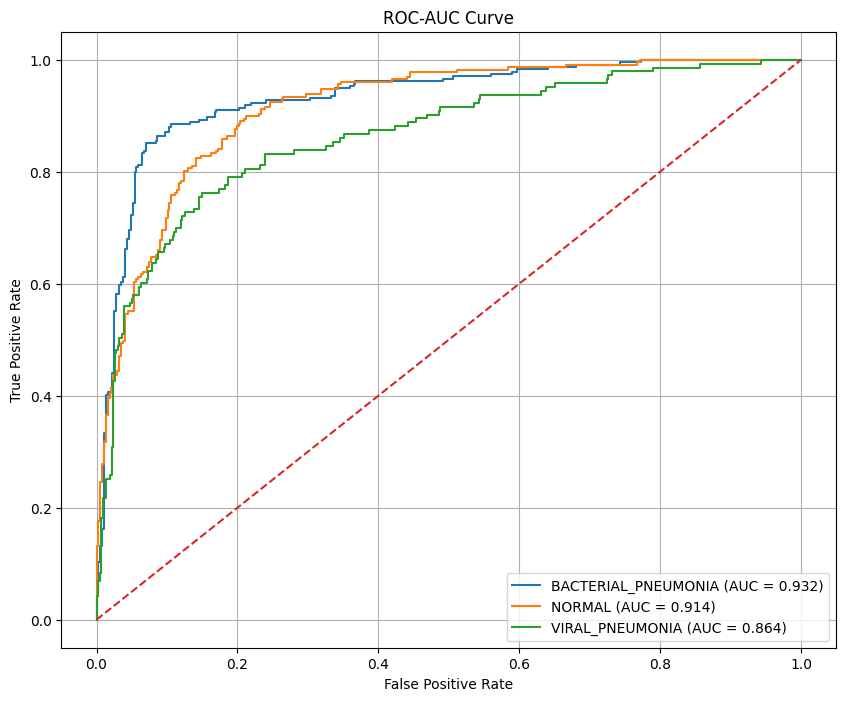

In [19]:
plt.figure(figsize=(10, 8))

for i in range(NUM_CLASSES):

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{prep.train_dataset.classes[i]} "
              f"(AUC = {roc_auc[i]:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC-AUC Curve")

plt.legend()
plt.grid()

plt.show()

In [20]:
overall_auc = roc_auc_score(
    labels_bin,
    probs,
    multi_class='ovr'
)

print(
    f"\nOverall ROC-AUC Score: "
    f"{overall_auc:.4f}"
)


Overall ROC-AUC Score: 0.9037


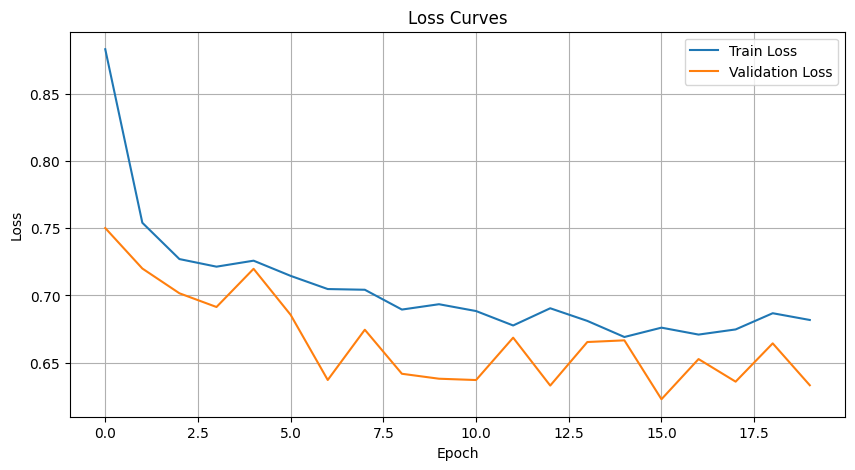

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Loss Curves")

plt.legend()
plt.grid()

plt.show()

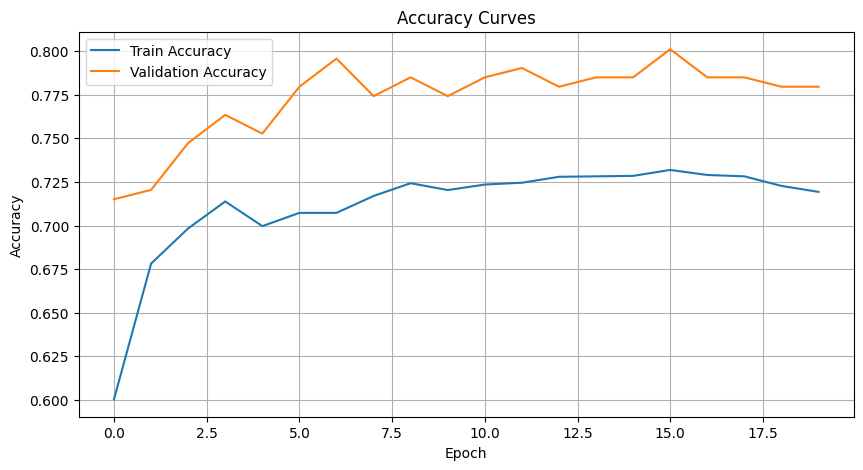

In [22]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_accuracies,
    label="Train Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Accuracy Curves")

plt.legend()
plt.grid()

plt.show()